In [1]:
import argparse
import os
from os import path
import sys
import olefile
import numpy as np

from scipy.ndimage import percentile_filter
import scipy.ndimage
import scipy.optimize

import sys

import h5writer
import h5py
import spts
import spts.camera
from spts.camera import CXDReader
import matplotlib.pyplot as plt
import matplotlib.cm
import matplotlib.patches
from matplotlib.colors import LogNorm
import random

In [2]:
#def make_circle_mask(diameter):
#    center = (diameter-1.) / 2.
#    x,y = np.meshgrid(np.arange(diameter), np.arange(diameter))
#    rsq = (x-center)**2 + (y-center)**2
#    mask = rsq <= center**2
#    return mask

In [2]:
bkgrnd_cxd = "/home/tejvarmay/scattering_data/data/newdata/data00449.cxd"#"/home/lenaw/Data/50nmPS/data01741.cxd"#"/home/tejvarmay/scattering_data/data/data01712.cxd"

reader = CXDReader(bkgrnd_cxd)
nframes = reader.get_number_of_frames()
frame0 = reader.get_frame(0)


bkgrnd_frames = np.zeros((nframes, frame0.shape[0], frame0.shape[1]))


for i in range(0,nframes): # Open frame by frame
    frame = reader.get_frame(i)#[xmin:xmax, ymin:ymax]
    bkgrnd_frames[i] = frame

mean_bkgrnd = np.mean(bkgrnd_frames, axis=0)


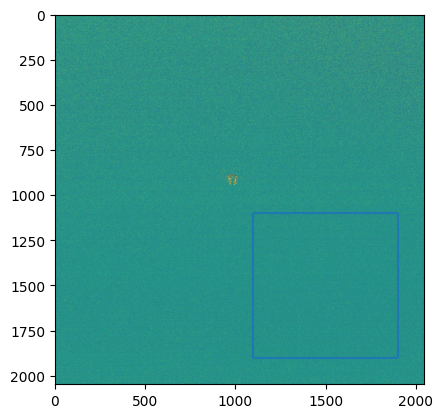

In [3]:
#framecorr=frame-mean_bkgrnd
#resizedframe = framecorr[0:1000,0:1000] # select only the upper left part where the particles typically are

frames_sub_mean = bkgrnd_frames - mean_bkgrnd

fig, ax = plt.subplots()
plt.imshow(frames_sub_mean[0], vmin=-20, vmax=20)

xmin, xmax = (1100,1900)
ymin, ymax = (1100,1900)

ax.vlines([xmin, xmax], ymin=ymin, ymax=ymax)
ax.hlines([ymin, ymax], xmin=xmin, xmax=xmax)

cropped_frames = frames_sub_mean[::5,xmin:xmax, ymin:ymax]

19


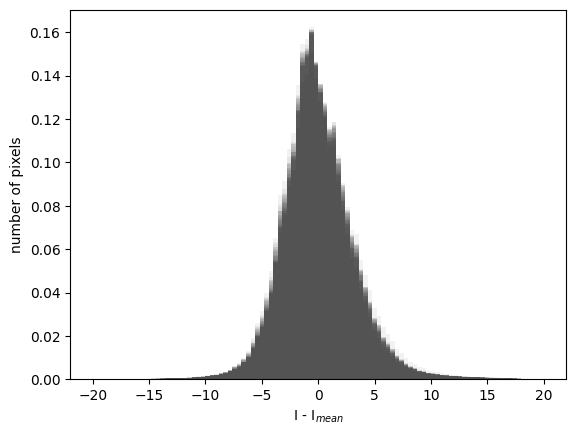

In [4]:
nbins= 100

vals = np.zeros((cropped_frames.shape[0], nbins))
for i, frame in enumerate(cropped_frames):
    print(i, end='\r')
    hist = plt.hist(frame.ravel(), bins = nbins, range = (-20,20),alpha=0.05,color=(0,0,0), density=True)
    vals[i] = hist[0]

bin_walls = hist[1]
bin_width = bin_walls[1]-bin_walls[1]
bin_mids = bin_walls[:-1]+bin_width/2
print()
plt.ylabel("number of pixels")
plt.xlabel("I - I$_{mean}$")

plt.show()

5.091407203798405


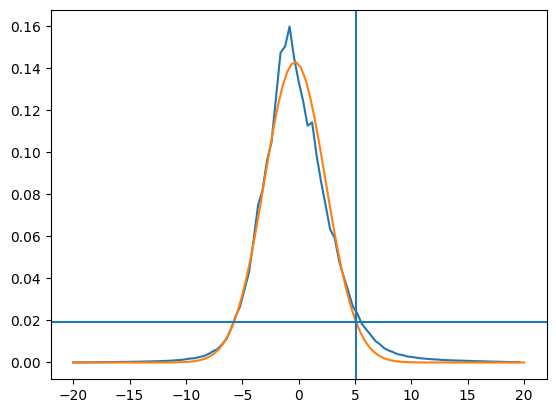

In [5]:
#plt.axvline(x=20+1/(np.e**2), ymin=0, ymax=4000)
plt.plot(bin_mids, vals.mean(axis=0))

bin_mids = np.linspace(-20,20, nbins)
def gauss(x, a, x0, sigma):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))
popt, pcov = scipy.optimize.curve_fit(gauss, bin_mids, vals.mean(axis=0))
plt.plot(bin_mids, gauss(bin_mids, *popt))

plt.axhline(popt[0]*1/(np.e**2))
plt.axvline(popt[1]+2*popt[2])

print(popt[1]+2*popt[2])


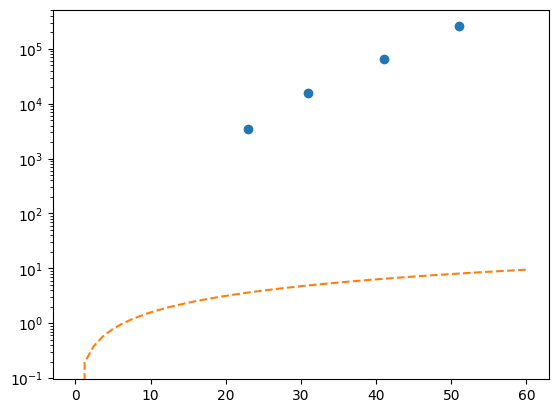

In [6]:
intensity_median = np.array([3.8867617794557576, 5.012705334775666, 6.337467749075303, 7.963337811205815])**6
diameter = np.array([23, 31, 41, 51])
diams = np.linspace(0, 60)
a_parts = np.array([0.1577886])
b_parts = np.array([0])
plt.plot(diameter, intensity_median, 'o')
plt.plot(diams, a_parts*diams+b_parts, '--')
plt.yscale('log')



In [8]:
popt[0]/(np.e**2), popt[1]+2*popt[2]

(np.float64(0.019334005470510857), np.float64(5.091407203798405))